In [1]:
import pandas as pd

In [2]:
data = {
    "Study_Hours" : [2, 3, 4, 5, 6, 7, 8, 9],
    "Attendance"  : [60, 65, 70, 75, 80, 85, 90, 95],
    "Assignment_Score" : [50, 55, 58, 65, 70, 74, 80, 88],
    "Final_Marks" : [42, 48, 54, 61, 67, 73, 81, 89]
}

df = pd.DataFrame(data)

In [3]:
df.to_csv('Dataset.csv', index = False)

In [4]:
df = pd.read_csv(r"C:\Users\bda\Desktop\261100660031\AML_LAB\Lab_5\Dataset.csv")

In [5]:
x = df.iloc[:,:-1]
x

,Study_Hours,Attendance,Assignment_Score
0,2,60,50
1,3,65,55
2,4,70,58
3,5,75,65
4,6,80,70
5,7,85,74
6,8,90,80
7,9,95,88


In [6]:
y = df.iloc[:,-1]
y

0    42
1    48
2    54
3    61
4    67
5    73
6    81
7    89
Name: Final_Marks, dtype: int64

In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [16]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [17]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])
print("Actual values : ", y_test.values)
print("Predicted values : ", y_pred)

Intercept :  -29.244102564102562
Slope :  0.14692307692307668
Actual values :  [48 73]
Predicted values :  [48.28       73.69333333]


In [18]:
print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.4866666666666717
MSE       :  0.27955555555556205
RMSE      :  0.5287301349039621
R-squared :  0.9982108444444444


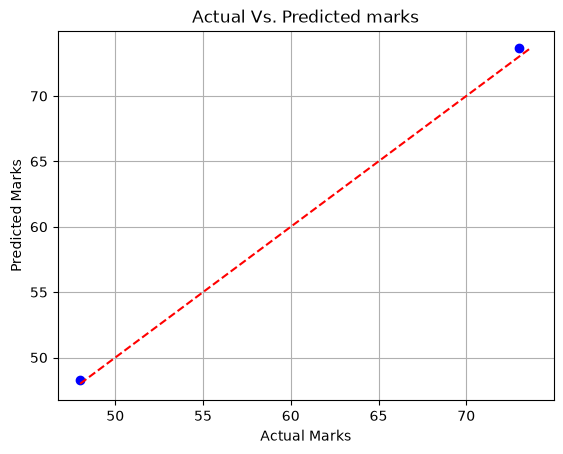

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color = "blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)


plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()

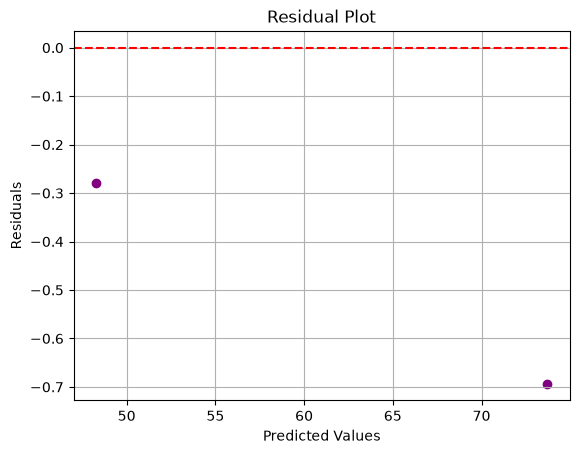

In [20]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color = "purple")
plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()